# Reaction Force vs Displacement — Cross-family Comparison

Compares the total reaction force (RF2 at PERN reference node) versus applied displacement (U2 at PERN reference node) across simulation families:

**Group 1:** 700s (static) · 750s (dynamic/implicit) · 760s (explicit)  
**Group 2:** 800s (static) · 850s (dynamic/implicit) · 860s (explicit)

- **Color** encodes the variant (same index within a family = same pressure/mesh configuration)
- **Line style** encodes the family: solid = 700/800 (static), dotted = 750/850 (dynamic), dashed = 760/860 (explicit)
- Missing PKL files are skipped gracefully

In [1]:
import sys, os, pickle
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.lines as mlines

sys.path.insert(0, os.path.abspath('..'))

RESULTS_DIR = '../I001_Results'


In [ ]:
def load_A_pkl(sim):
    """Load _A.pkl for a given simulation number. Returns None if not found."""
    path = os.path.join(RESULTS_DIR, f'DATA_PICK_{sim}_A.pkl')
    if not os.path.exists(path):
        return None
    with open(path, 'rb') as f:
        return pickle.load(f)


def extract_rf_disp(d):
    """
    Extract displacement and reaction force from a loaded _A.pkl dict.

    U2 at PERN-9999997 is the prescribed platen displacement (Step-1 boundary condition).
    RF2 at PERN-9999997 is the conjugate reaction force on the loading platen.
    Both are relative to the start of the recorded step and returned as positive magnitudes.
    """
    u2_raw = np.array(d['U2']['PERN-9999997']['9999997'])
    rf2_raw = np.array(d['RF2']['PERN-9999997']['9999997'])
    # Subtract initial value in case Step-0 left a residual displacement
    u2 = np.abs(u2_raw - u2_raw[0])
    rf2 = np.abs(rf2_raw)
    return u2, rf2


def load_family(base, n_variants=10):
    """
    Load all available sims in range [base, base+n_variants).
    Returns dict: {variant_index: (u2, rf2)}
    """
    data = {}
    for i in range(n_variants):
        sim = base + i
        d = load_A_pkl(sim)
        if d is not None:
            data[i] = extract_rf_disp(d)
            print(f'  SIM {sim} (variant {i}): loaded, {len(data[i][0])} time steps')
    return data


In [3]:
# --- Group 1: 700s / 750s / 760s ---
print('Loading family 700 (static)...')
fam700 = load_family(700)
print('Loading family 750 (dynamic/implicit)...')
fam750 = load_family(750)
print('Loading family 760 (explicit)...')
fam760 = load_family(760)

# --- Group 2: 800s / 850s / 860s ---
print('\nLoading family 800 (static)...')
fam800 = load_family(800)
print('Loading family 850 (dynamic/implicit)...')
fam850 = load_family(850)
print('Loading family 860 (explicit)...')
fam860 = load_family(860)


Loading family 700 (static)...
  SIM 700 (variant 0): loaded, 201 time steps
  SIM 701 (variant 1): loaded, 201 time steps
  SIM 702 (variant 2): loaded, 201 time steps
  SIM 703 (variant 3): loaded, 201 time steps
  SIM 704 (variant 4): loaded, 201 time steps
  SIM 705 (variant 5): loaded, 201 time steps
Loading family 750 (dynamic/implicit)...
Loading family 760 (explicit)...

Loading family 800 (static)...
  SIM 800 (variant 0): loaded, 201 time steps
  SIM 801 (variant 1): loaded, 201 time steps
  SIM 802 (variant 2): loaded, 201 time steps
  SIM 803 (variant 3): loaded, 201 time steps
  SIM 804 (variant 4): loaded, 201 time steps
Loading family 850 (dynamic/implicit)...
  SIM 850 (variant 0): loaded, 201 time steps
Loading family 860 (explicit)...


In [4]:
# Color palette: one color per variant index (up to 10 variants)
CMAP = plt.get_cmap('tab10')

# Line styles per family type
STYLES = {
    'static':   '-',
    'dynamic':  ':',
    'explicit': '--',
}
LINEWIDTH = 1.8


def plot_family(ax, family_data, label_prefix, style_key, already_labeled_variants):
    """
    Plot all variants of one family onto ax.
    Adds a legend entry only for the first family that introduces each variant color.
    already_labeled_variants: set of variant indices already added to the legend.
    """
    ls = STYLES[style_key]
    for variant_idx, (u2, rf2) in sorted(family_data.items()):
        color = CMAP(variant_idx)
        lbl = f'Variant {variant_idx}' if variant_idx not in already_labeled_variants else '_nolegend_'
        ax.plot(u2, rf2, color=color, ls=ls, lw=LINEWIDTH, label=lbl)
        already_labeled_variants.add(variant_idx)


## Group 1 — 700s (static) · 750s (dynamic) · 760s (explicit)

/tmp/ipykernel_1452691/3002355534.py:14: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  variant_legend = ax1.legend(loc='upper left', fontsize=9, title='Variant (pressure)', framealpha=0.8)


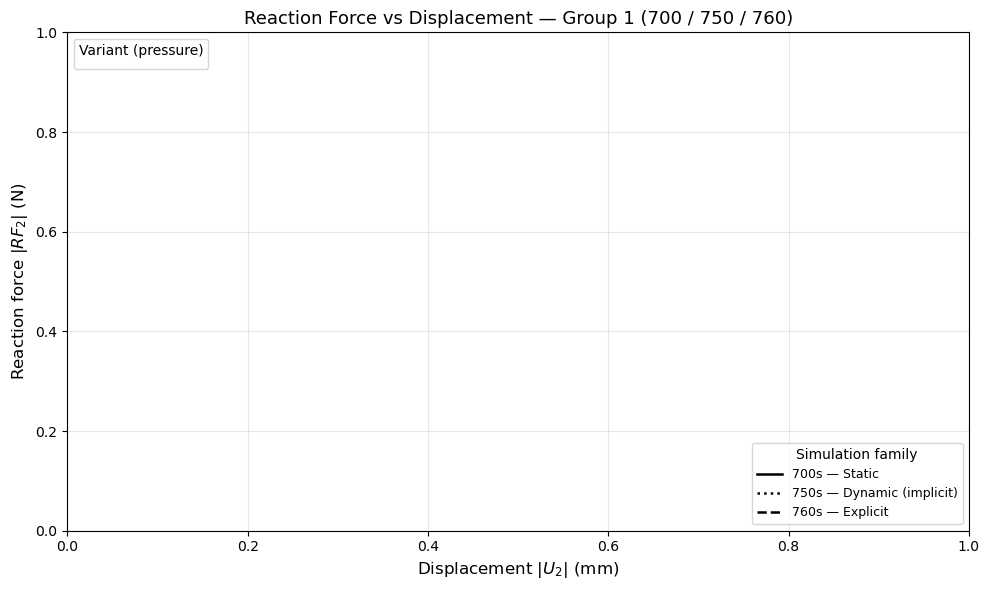

In [ ]:
fig1, ax1 = plt.subplots(figsize=(10, 6))

labeled_variants = set()
plot_family(ax1, fam700, '700', 'static',   labeled_variants)
plot_family(ax1, fam750, '750', 'dynamic',  labeled_variants)
plot_family(ax1, fam760, '760', 'explicit', labeled_variants)

ax1.set_xlabel('Displacement $|U_2|$ (mm)', fontsize=12)
ax1.set_ylabel('Reaction force $|RF_2|$ (N)', fontsize=12)
ax1.set_title('Reaction Force vs Displacement — Group 1 (700 / 750 / 760)', fontsize=13)
ax1.grid(True, alpha=0.3)

# Legend: variant colors
variant_legend = ax1.legend(loc='upper left', fontsize=9, title='Variant (pressure)', framealpha=0.8)
ax1.add_artist(variant_legend)

# Second legend: line styles for families
style_handles = [
    mlines.Line2D([], [], color='k', ls='-',  lw=LINEWIDTH, label='700s — Static'),
    mlines.Line2D([], [], color='k', ls=':',  lw=LINEWIDTH, label='750s — Dynamic (implicit)'),
    mlines.Line2D([], [], color='k', ls='--', lw=LINEWIDTH, label='760s — Explicit'),
]
ax1.legend(handles=style_handles, loc='lower right', fontsize=9, title='Simulation family', framealpha=0.8)

fig1.tight_layout()
plt.show()


## Group 2 — 800s (static) · 850s (dynamic) · 860s (explicit)

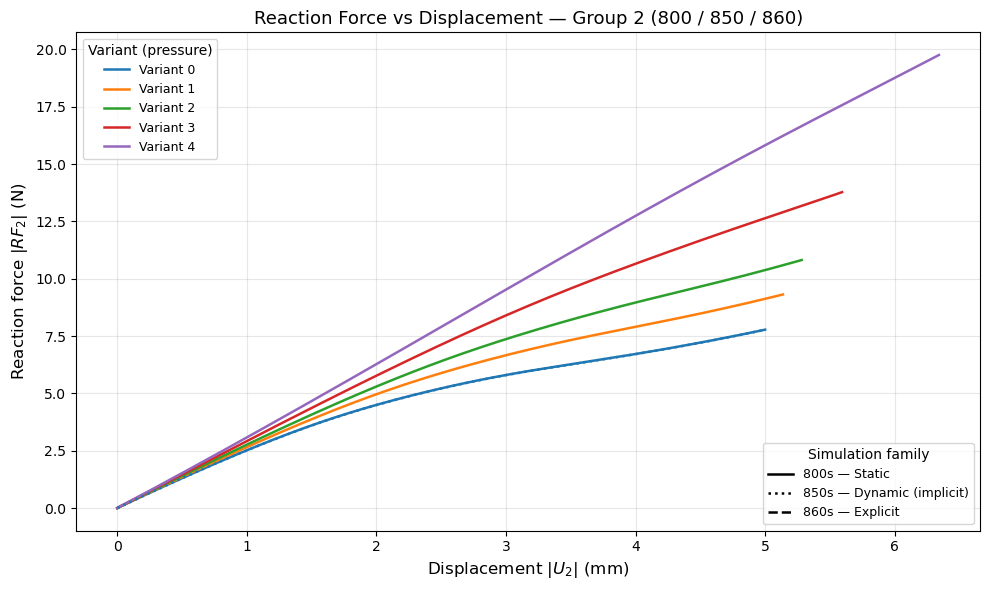

In [8]:
fig2, ax2 = plt.subplots(figsize=(10, 6))

labeled_variants = set()
plot_family(ax2, fam800, '800', 'static',   labeled_variants)
plot_family(ax2, fam850, '850', 'dynamic',  labeled_variants)
plot_family(ax2, fam860, '860', 'explicit', labeled_variants)

ax2.set_xlabel('Displacement $|U_2|$ (mm)', fontsize=12)
ax2.set_ylabel('Reaction force $|RF_2|$ (N)', fontsize=12)
ax2.set_title('Reaction Force vs Displacement — Group 2 (800 / 850 / 860)', fontsize=13)
ax2.grid(True, alpha=0.3)

# Legend: variant colors
variant_legend = ax2.legend(loc='upper left', fontsize=9, title='Variant (pressure)', framealpha=0.8)
ax2.add_artist(variant_legend)

# Second legend: line styles for families
style_handles = [
    mlines.Line2D([], [], color='k', ls='-',  lw=LINEWIDTH, label='800s — Static'),
    mlines.Line2D([], [], color='k', ls=':',  lw=LINEWIDTH, label='850s — Dynamic (implicit)'),
    mlines.Line2D([], [], color='k', ls='--', lw=LINEWIDTH, label='860s — Explicit'),
]
ax2.legend(handles=style_handles, loc='lower right', fontsize=9, title='Simulation family', framealpha=0.8)

fig2.tight_layout()
plt.show()
